In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./train.csv", index_col="Id")
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Sanity Checks

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

We have 79 features that would help predict the sales price for houses. As we can see, there are a total of 1,460 rows for each features (including null values). For the null values, we will highlight below.

## Null Value Handling

In [5]:
null_cols = df.columns[df.isnull().any()]
print(null_cols)
print(f"\n {len(null_cols)} columns that contain null values.")

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='str')

 19 columns that contain null values.


## Might be deleted lol

### LotFrontage

In [6]:
df[df['LotFrontage'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
13,20,RL,NaN,12968,Pave,NaN,IR2,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,144000
15,20,RL,NaN,10920,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,GdWo,NaN,0,5,2008,WD,Normal,157000
17,20,RL,NaN,11241,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,Shed,700,3,2010,WD,Normal,149000
25,20,RL,NaN,8246,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1430,20,RL,NaN,12546,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2007,WD,Normal,182900
1432,120,RL,NaN,4928,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,143750
1442,120,RM,NaN,4426,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,149300


Description for *LotFrontage* is as follows:

**LotFrontage: Linear feet of street connected to property**

Imputing zeroes for null values make sense as it is possible to have properties not having street connected to them, such as "landlocked properties".

In [7]:
df["LotFrontage"] = df["LotFrontage"].fillna(0)

### Alley

Description for *Alley* is as follows:


| **Alley** | **Type of alley access to property** |
| :--- | :--- |
| **Grvl** | Gravel |
| **Pave** | Paved |
| **NA** | No alley access |

Imputing zeroes for null values make sense as it "No alley access" = "None". 

In [8]:
df[df['Alley'].isnull()].head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
df["Alley"] = df["Alley"].fillna("None")

### Masonry

Description for *MasVnrType* & *MasVnrArea*:

**1. MasVnrType: Masonry veneer type**

| Code | Description |
| :--- | :--- |
| BrkCmn | Brick Common |
| BrkFace | Brick Face |
| CBlock | Cinder Block |
| None | None |
| Stone | Stone |


**MasVnrArea: Masonry veneer area in square feet**



In [10]:
mas_df = df[['MasVnrType', 'MasVnrArea']]
mas_df[mas_df['MasVnrType'].isnull()]

,MasVnrType,MasVnrArea
Id,,
2,NaN,0.0
4,NaN,0.0
6,NaN,0.0
9,NaN,0.0
10,NaN,0.0
...,...,...
1455,NaN,0.0
1456,NaN,0.0
1458,NaN,0.0


We can confirm those with 0 or N/A *MasVnrArea* have N/A *MasVnrType*. We can impute with "None"

In [11]:
df[['MasVnrType', 'MasVnrArea']].fillna("None")

,MasVnrType,MasVnrArea
Id,,
1,BrkFace,196.0
2,None,0.0
3,BrkFace,162.0
4,None,0.0
5,BrkFace,350.0
...,...,...
1456,None,0.0
1457,Stone,119.0
1458,None,0.0


### Basement

**1. BsmtQual: Evaluates the height of the basement**

| Code | Description |
| :--- | :--- |
| Ex | Excellent (100+ inches) |
| Gd | Good (90-99 inches) |
| TA | Typical (80-89 inches) |
| Fa | Fair (70-79 inches) |
| Po | Poor (<70 inches) |
| NA | No Basement |

***

**2. BsmtCond: Evaluates the general condition of the basement**

| Code | Description |
| :--- | :--- |
| Ex | Excellent |
| Gd | Good |
| TA | Typical - slight dampness allowed |
| Fa | Fair - dampness or some cracking or settling |
| Po | Poor - Severe cracking, settling, or wetness |
| NA | No Basement |

***

**3. BsmtExposure: Refers to walkout or garden level walls**

| Code | Description |
| :--- | :--- |
| Gd | Good Exposure |
| Av | Average Exposure (split levels or foyers typically score average or above) |
| Mn | Minimum Exposure |
| No | No Exposure |
| NA | No Basement |

***

**4. BsmtFinType1: Rating of basement finished area**

| Code | Description |
| :--- | :--- |
| GLQ | Good Living Quarters |
| ALQ | Average Living Quarters |
| BLQ | Below Average Living Quarters |
| Rec | Average Rec Room |
| LwQ | Low Quality |
| Unf | Unfinished |
| NA | No Basement |

***

**5. BsmtFinType2: Rating of basement finished area (if multiple types)**

| Code | Description |
| :--- | :--- |
| GLQ | Good Living Quarters |
| ALQ | Average Living Quarters |
| BLQ | Below Average Living Quarters |
| Rec | Average Rec Room |
| LwQ | Low Quality |
| Unf | Unfinished |
| NA | No Basement |

***

* **BsmtFinSF1: Type 1 finished square feet**
* **BsmtFinSF2: Type 2 finished square feet**
* **BsmtUnfSF: Unfinished square feet of basement area**
* **TotalBsmtSF: Total square feet of basement area**

In [12]:
bsmnt_df = df[['BsmtQual','BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']]
bsmnt_df[bsmnt_df['BsmtQual'].isnull()].head()

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
Id,,,,,
18,NaN,NaN,NaN,NaN,NaN
40,NaN,NaN,NaN,NaN,NaN
91,NaN,NaN,NaN,NaN,NaN
103,NaN,NaN,NaN,NaN,NaN
157,NaN,NaN,NaN,NaN,NaN


In [13]:
df[['BsmtQual','BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']].fillna("None")

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
Id,,,,,
1,Gd,TA,No,GLQ,Unf
2,Gd,TA,Gd,ALQ,Unf
3,Gd,TA,Mn,GLQ,Unf
4,TA,Gd,No,ALQ,Unf
5,Gd,TA,Av,GLQ,Unf
...,...,...,...,...,...
1456,Gd,TA,No,Unf,Unf
1457,Gd,TA,No,ALQ,Rec
1458,TA,Gd,No,GLQ,Unf


### Garage

**1. GarageType: Garage location**

| Code | Description |
| :--- | :--- |
| 2Types | More than one type of garage |
| Attchd | Attached to home |
| Basment | Basement Garage |
| BuiltIn | Built-In (Garage part of house - typically has room above garage) |
| CarPort | Car Port |
| Detchd | Detached from home |
| NA | No Garage |

***

**2. GarageFinish: Interior finish of the garage**

| Code | Description |
| :--- | :--- |
| Fin | Finished |
| RFn | Rough Finished |
| Unf | Unfinished |
| NA | No Garage |

***

**3. GarageQual: Garage quality**

| Code | Description |
| :--- | :--- |
| Ex | Excellent |
| Gd | Good |
| TA | Typical/Average |
| Fa | Fair |
| Po | Poor |
| NA | No Garage |

***
**4. GarageCond: Garage condition**

| Code | Description |
| :--- | :--- |
| Ex | Excellent |
| Gd | Good |
| TA | Typical/Average |
| Fa | Fair |
| Po | Poor |
| NA | No Garage |
***
*   **GarageYrBlt: Year garage was built**
*   **GarageCars: Size of garage in car capacity**
*   **GarageArea: Size of garage in square feet**

In [14]:
garage_df = df[['GarageType', 'GarageYrBlt','GarageFinish', 'GarageQual', 'GarageCond']]
garage_df[garage_df['GarageType'].isnull()].head()

,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond
Id,,,,,
40,NaN,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN,NaN
90,NaN,NaN,NaN,NaN,NaN


In [15]:
df[['GarageType', 'GarageYrBlt','GarageFinish', 'GarageQual', 'GarageCond']].fillna("None")

,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond
Id,,,,,
1,Attchd,2003.0,RFn,TA,TA
2,Attchd,1976.0,RFn,TA,TA
3,Attchd,2001.0,RFn,TA,TA
4,Detchd,1998.0,Unf,TA,TA
5,Attchd,2000.0,RFn,TA,TA
...,...,...,...,...,...
1456,Attchd,1999.0,RFn,TA,TA
1457,Attchd,1978.0,Unf,TA,TA
1458,Attchd,1941.0,RFn,TA,TA


### The Rest

We have *Electrical*, *FireplaceQu*, *PoolQC*, *Fence* & *MiscFeatures* left. These follow the very simple intuition - "If it does not exist, then N/A". Therefore, they will all be filled with "None"

In [16]:
df[['Electrical', 'FireplaceQu','PoolQC', 'Fence', 'MiscFeature']].fillna("None")

,Electrical,FireplaceQu,PoolQC,Fence,MiscFeature
Id,,,,,
1,SBrkr,None,None,None,None
2,SBrkr,TA,None,None,None
3,SBrkr,TA,None,None,None
4,SBrkr,Gd,None,None,None
5,SBrkr,TA,None,None,None
...,...,...,...,...,...
1456,SBrkr,TA,None,None,None
1457,SBrkr,TA,None,MnPrv,None
1458,SBrkr,Gd,None,GdPrv,Shed


In [17]:
still_null = []
for col in df.columns:
    if df[col].isnull().any() == True:
        still_null.append(col)
else:
    print("No Null Values!")

No Null Values!


# The Target Column: Price

In [18]:
df["SalePrice"] = np.log(df["SalePrice"])

<Axes: xlabel='Id'>

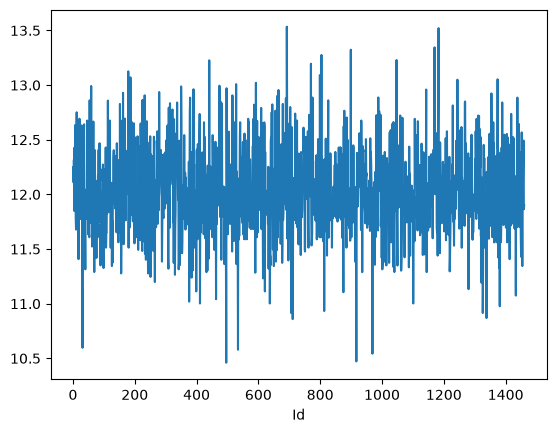

In [19]:
df["SalePrice"].plot()

In [20]:
df["SalePrice"].describe()

count    1460.000000
mean       12.024051
std         0.399452
min        10.460242
25%        11.775097
50%        12.001505
75%        12.273731
max        13.534473
Name: SalePrice, dtype: float64

<Axes: ylabel='SalePrice'>

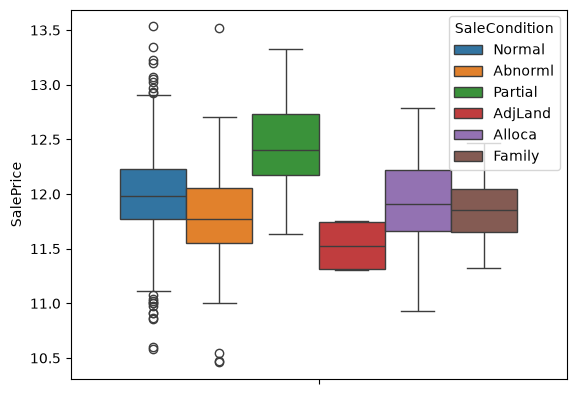

In [23]:
sns.boxplot(df, y=df["SalePrice"], hue=df["SaleCondition"])

In [24]:
cat_cols = df.select_dtypes(include="str").columns.tolist()
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [25]:
df[cat_cols] = df[cat_cols].astype('category')

In [26]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
import xgboost as xgb

dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

params = {"objective" : "reg:squarederror",
          "tree_method" : "hist",
          "learning_rate" : 0.03,
          }

evals = [(dtrain_reg, 'train'), (dtest_reg, 'eval')]

evals_result = {}
xgb_model = xgb.train(
    params=params,
    dtrain=dtrain_reg,
    evals=evals,
    num_boost_round=1000,
    early_stopping_rounds = 100,
    verbose_eval=100,
    evals_result=evals_result
)


[0]	train-rmse:0.38056	eval-rmse:0.42329
[100]	train-rmse:0.05967	eval-rmse:0.14549
[200]	train-rmse:0.03095	eval-rmse:0.13472
[300]	train-rmse:0.02320	eval-rmse:0.13406
[387]	train-rmse:0.01860	eval-rmse:0.13422


Text(0, 0.5, 'rmse')

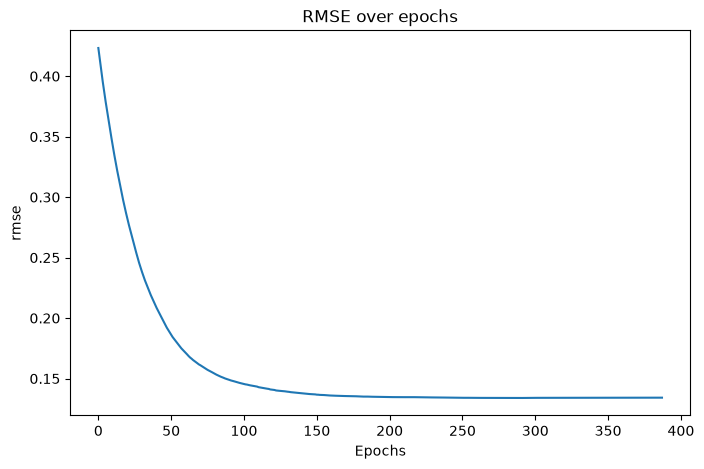

In [46]:
evaluations = evals_result.get('eval')['rmse']

plt.figure(figsize=(8,5))
sns.lineplot(evaluations)
plt.title("RMSE over epochs")
plt.xlabel("Epochs")
plt.ylabel("rmse")